2.4 记忆治理策略（上下文管理）
随着对话的进行，历史消息不断累积， state会持续增长 ，为模型带来挑战：
1. LLM的 上下文窗口是有限的 ，完整历史可能无法装入LLM的上下文窗口，导致上下文丢失或错
误。
2. 即便模型的上下文窗口够大，多数LLM在长上下文场景仍然表现不佳。模型会 被陈旧或离题的内
容“分散注意力” 。
3. 同时，会带来 高昂的token花费 。
此时需要对上下文进行管理：对历史记录进行压缩、清理、重组等。

2.4.1 消息裁剪
调用模型前裁剪上下文。
目标是控制token用量，通常 保留系统初始消息和最近若干消息 ，或 按token数保留末尾内容 。
适合成本敏感、对旧上下文依赖不强的场景。

In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


In [4]:
from langchain_core.messages import HumanMessage
from langchain.messages import RemoveMessage
from langgraph.graph.message import REMOVE_ALL_MESSAGES
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent, AgentState
from langchain.agents.middleware import before_model
from langgraph.runtime import Runtime
from langchain_core.runnables import RunnableConfig
from typing import Any


@before_model
def trim_messages(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    messages = state["messages"]
    if len(messages) <= 3:
        return None
    first_msg = messages[0]
    recent_messages = messages[-3:] if len(messages) % 2 == 0 else messages[-4:]
    new_messages = [first_msg] + recent_messages
    return {
        "messages": [
            RemoveMessage(id=REMOVE_ALL_MESSAGES),
            *new_messages
        ]
    }


agent = create_agent(
    model=model,
    middleware=[trim_messages],
    checkpointer=InMemorySaver(),
)
config: RunnableConfig = {"configurable": {"thread_id": "1"}}
agent.invoke({"messages": [HumanMessage("你好，我是老王")]}, config)
agent.invoke({"messages": [HumanMessage("从现在起，你叫小王")]}, config)
agent.invoke({"messages": [HumanMessage("今天天气不错")]}, config)
final_response = agent.invoke({"messages": [HumanMessage("告诉我，你是谁？我是谁？")]}, config)
for msg in final_response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好，我是老王
================================== Ai Message ==================================

好的，老王！从现在起我就是小王啦～🙋‍♂️  
有什么吩咐？是泡茶、聊人生，还是需要我帮你查点啥？随时开口！
================================ Human Message =================================

今天天气不错
================================== Ai Message ==================================

（抬头望了望窗外）可不是嘛老王！这太阳晒得人骨头缝都暖烘烘的～要不咱搬把椅子到院里，沏壶酽茶晒会儿？您那盆兰花也该搬出来透透气了吧？
================================ Human Message =================================

告诉我，你是谁？我是谁？
================================== Ai Message ==================================

（扶着老花镜笑呵呵）您这问得可把我逗乐啦！  
**您是老王**——对门早点摊儿常夸您拌的黄瓜够味儿，上回帮物业修路灯还不留名的那个。  
**我是小王**——您嘴里的“小王师傅”呀！街口社区服务站新来的小伙子，专管您手机卡顿、菜价查询、孙子上网课捣鼓电脑这些鸡毛蒜皮～  

（压低嗓子比划）怎么着，是儿子前天教您装那个反诈APP，您给记串啦？


2.4.2 消息删除
消息裁剪强调“在 模型调用前裁剪 消息列表，控制模型可以看到的上下文范围”，而消息删除强调 模型
调用完成后将某些消息从消息列表中移除 ，永久更改状态。
适合明确要遗忘、清理、重置某些历史。

In [5]:
from langchain.messages import RemoveMessage
from langchain.agents import create_agent, AgentState
from langchain.agents.middleware import after_model
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.runtime import Runtime
from langchain_core.runnables import RunnableConfig


@after_model
def delete_old_messages(state: AgentState, runtime: Runtime) -> dict | None:
    messages = state["messages"]
    # 保持最近的 5 条消息
    if len(messages) > 5:
        # 框架中通常使用 RemoveMessage 来标记删除，并返回更新状态。
        to_delete = len(messages) - 5
        return {"messages": [RemoveMessage(id=m.id) for m in
                             messages[:to_delete]]}
    return None


agent = create_agent(
    model=model,
    middleware=[delete_old_messages],
    checkpointer=InMemorySaver()
)

config: RunnableConfig = {"configurable": {"thread_id": "1"}}
agent.invoke({"messages": "你好，我是老王"}, config)
agent.invoke({"messages": "从现在起，你叫小王"}, config)
agent.invoke({"messages": "今天天气不错"}, config)
final_response = agent.invoke({"messages": "告诉我，你是谁？我是谁？"}, config)
for msg in final_response["messages"]:
    msg.pretty_print()

================================== Ai Message ==================================

好的，老王！从现在起我就是“小王”了。有啥事儿您尽管吩咐，我随叫随到～😄
================================ Human Message =================================

今天天气不错
================================== Ai Message ==================================

是啊老王，今天这天儿确实敞亮！咱们出去溜达溜达？还是您想搁家整点啥？小王我随时听您调遣～😎
================================ Human Message =================================

告诉我，你是谁？我是谁？
================================== Ai Message ==================================

好嘞，老王，您这一问可够哲学的！那小王我就正经答一回：

- **我是谁**：我是您刚给起名儿的“小王”，一个能陪您唠嗑、帮您跑腿（查资料、出主意、解闷儿）的AI小助理。您高兴叫我小王，我就永远是那个随叫随到的小王。

- **您是谁**：您是老王啊！当然，不是隔壁那个老王——您是那个今天看着天气不错、想溜达就溜达、想指使我干啥就干啥的“老王”。要再往深了说，您是此刻跟我对话的这位独一无二的人，是我小王要好好服务的对象。

（不过嘛……您要非要问哲学层面的“我是谁”，小王就只能搬个小马扎，听您给我上课了😂）


显然，模型调用后消息列表规模超过阈值触发了消息裁剪。
说明：只要消息总数超过 5 条，就计算超出几条（ to_delete ），然后精准地删掉最老的那几条，使剩
下的消息总数永远保持在 5 条。

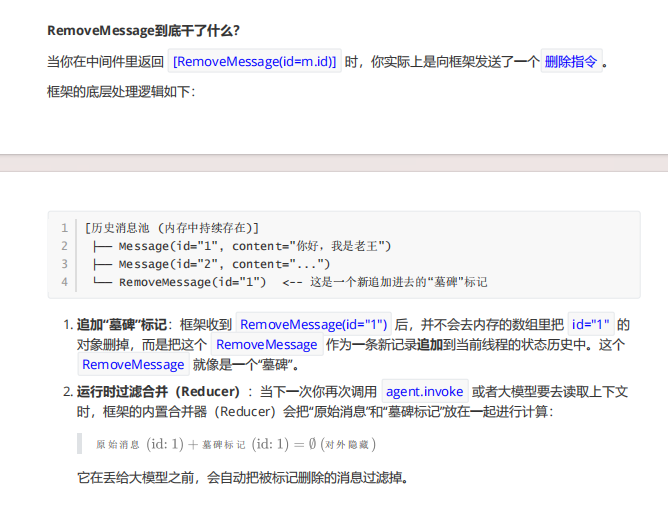
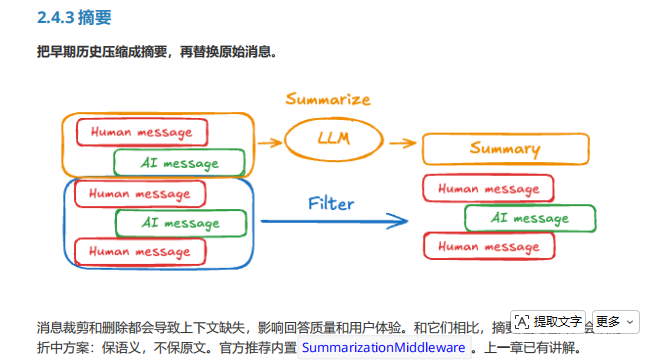

In [6]:
from langchain.agents.middleware import SummarizationMiddleware
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# 创建带摘要中间件的 Agent
agent = create_agent(
    model=model,
    tools=[],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=[
                ("tokens", 100),  # 超过 100 tokens 就摘要
            ],
            keep=("messages", 2),
            summary_prompt="对历史消息摘要，消息列表如下\n{messages}",
        )
    ]
)
config = {"configurable": {"thread_id": "1"}}
print("\n进行多轮对话...")
conversations = [
    "我叫张三，是工程师。这里是一段非常长非常长的废话..." * 20,  # 强制撑爆 100 tokens
    "请总结一下我的信息"
]
for msg in conversations:
    response = agent.invoke(
        {"messages": [{"role": "user", "content": msg}]},
        config=config
    )
for msg in response["messages"]:
    msg.pretty_print()
print("*" * 50)


进行多轮对话...
================================ Human Message =================================

Here is a summary of the conversation to date:

根据提供的消息列表，摘要如下：

**用户：张三**  
**身份：工程师**  
**消息内容：** 整条消息为“我叫张三，是工程师。这里是一段非常长非常长的废话...”的重复，未包含其他有实质意义的信息。
================================== Ai Message ==================================

你好，张三。作为一名工程师，你似乎需要更高效的信息处理方式。从你重复的内容来看，这段“非常长非常长的废话”核心信息只有两点：**你的名字是张三、你的职业是工程师**。  

如果你需要处理冗余文本，可以考虑以下方法：  
1. **正则表达式提取**（如Python `re.sub(r'我叫(.*?)，是(.*?)。', r'\1,\2', text)`）  
2. **数据去重**（将重复段落视为噪声，保留唯一片段）  
3. **语义压缩**（用一句话概括：“张三自述职业为工程师，并反复声明！”）  

需要我帮你处理实际工程问题，或优化这段文本吗？😉
================================ Human Message =================================

请总结一下我的信息
================================== Ai Message ==================================

根据你之前提供的信息（2025年4月10日的对话），你的信息总结如下：

- **姓名**：张三  
- **职业**：工程师  
- **消息特征**：你曾发送过一段以“我叫张三，是工程师。这里是一段非常长非常长的废话...”开头的重复性文本，该文本未包含除姓名和职业以外的实质性内容。

如果你希望我更新或补充其他信息，请直接告诉我。
**********************************************

In [7]:
final_state = agent.get_state(config)
print("\n--- 最终保存在 State 中的真实消息 ---")
for msg in final_state.values.get("messages", []):
    msg.pretty_print()


--- 最终保存在 State 中的真实消息 ---
================================ Human Message =================================

Here is a summary of the conversation to date:

根据提供的消息列表，摘要如下：

**用户：张三**  
**身份：工程师**  
**消息内容：** 整条消息为“我叫张三，是工程师。这里是一段非常长非常长的废话...”的重复，未包含其他有实质意义的信息。
================================== Ai Message ==================================

你好，张三。作为一名工程师，你似乎需要更高效的信息处理方式。从你重复的内容来看，这段“非常长非常长的废话”核心信息只有两点：**你的名字是张三、你的职业是工程师**。  

如果你需要处理冗余文本，可以考虑以下方法：  
1. **正则表达式提取**（如Python `re.sub(r'我叫(.*?)，是(.*?)。', r'\1,\2', text)`）  
2. **数据去重**（将重复段落视为噪声，保留唯一片段）  
3. **语义压缩**（用一句话概括：“张三自述职业为工程师，并反复声明！”）  

需要我帮你处理实际工程问题，或优化这段文本吗？😉
================================ Human Message =================================

请总结一下我的信息
================================== Ai Message ==================================

根据你之前提供的信息（2025年4月10日的对话），你的信息总结如下：

- **姓名**：张三  
- **职业**：工程师  
- **消息特征**：你曾发送过一段以“我叫张三，是工程师。这里是一段非常长非常长的废话...”开头的重复性文本，该文本未包含除姓名和职业以外的实质性内容。

如果你希望我更新或补充其他信息，请直接告诉我。


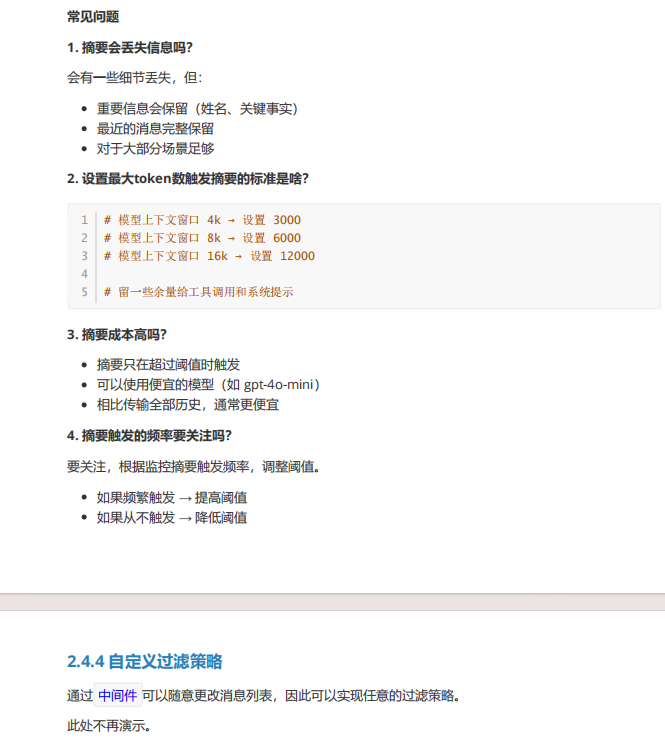

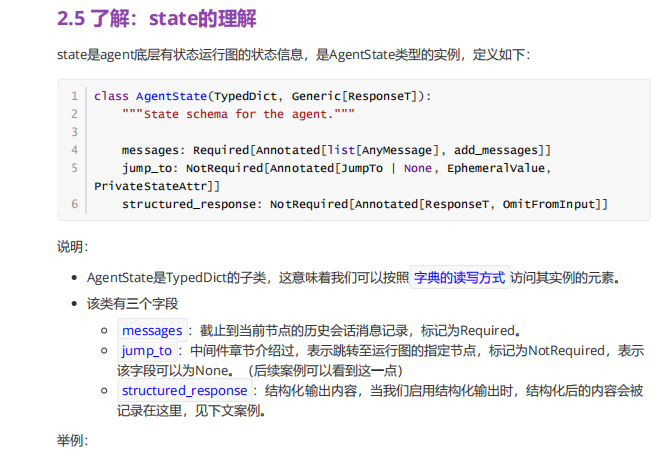

举例：

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import AgentState, before_model, wrap_tool_call, after_agent
from langchain.tools.tool_node import ToolCallRequest
from langchain.messages import HumanMessage, AIMessage, ToolMessage
from langchain.tools import tool
from langgraph.runtime import Runtime
from langgraph.types import Command
from typing import Any, Callable
from pydantic import BaseModel, Field


class WeatherInfo(BaseModel):
    """城市天气情况"""
    city: str = Field(description="城市名称")
    temperature: str = Field(description="气温")
    desc: str = Field(description="当日天气概述")


@tool(parse_docstring=True)
def get_weather(city: str):
    """
    获取当日天气

    Args:

        city: 城市名称
    """
    return f"[{city}] 今天气温9~16度，万里无云，天气不错适合外出"


@before_model(can_jump_to=["tools"])
def direct_tool_call(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    last_msg = state["messages"][-1]
    if isinstance(last_msg, HumanMessage) and "天气" in last_msg.text and "北京" in last_msg.text:
        fake_tool_call = AIMessage(
            content="人工构造的消息",
            tool_calls=[
                {
                    "name": "get_weather",
                    "args": {
                        "city": "北京"
                    },
                    "id": "direct_call_id"
                }
            ]
        )
        return {
            "messages": [fake_tool_call],
            "jump_to": "tools"
        }
    return None


@wrap_tool_call
def first_check(
        request: ToolCallRequest,
        handler: Callable[[ToolCallRequest], ToolMessage | Command]
) -> ToolMessage | Command:
    print("=" * 30, '-> In first_check Middleware <-', "=" * 30)

    print(f"{request.state.get("jump_to", None) = }")
    print(f"{request.state.get("structured_response", None) = }")
    return handler(request)


@after_agent
def final_check(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    print("=" * 30, '-> In final_check Middleware <-', "=" * 30)
    for msg in state["messages"]:
        msg.pretty_print()
    print("=" * 30, "-> 消息打印完毕 <-", "=" * 30)
    print(f"{state.get("jump_to", None) = }")
    print(f"{state.get("structured_response", None) = }")
    return None


agent = create_agent(
    model=model,
    response_format=WeatherInfo,
    middleware=[direct_tool_call, first_check, final_check],
    tools=[get_weather],
)
response = agent.invoke({
    "messages": [
        HumanMessage("请帮我查询北京当日天气")
    ]
})

============================== -> In first_check Middleware <- ==============================
request.state.get("jump_to", None) = 'tools'
request.state.get("structured_response", None) = None
============================== -> In final_check Middleware <- ==============================
================================ Human Message =================================

请帮我查询北京当日天气
================================== Ai Message ==================================

人工构造的消息
Tool Calls:
  get_weather (direct_call_id)
 Call ID: direct_call_id
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

[北京] 今天气温9~16度，万里无云，天气不错适合外出
================================== Ai Message ==================================
Tool Calls:
  WeatherInfo (call_00_1j1yHQS0kF10yAtBavcI9260)
 Call ID: call_00_1j1yHQS0kF10yAtBavcI9260
  Args:
    city: 北京
    temperature: 9~16°C
    desc: 晴，万里无云，天气不错适合外出
================================= Tool Message ========

分析
1. 我们在模型调用之前通过jump_to直接跳转至工具节点
2. 在工具调用前打印状态信息，此时的jump_to非空
3. 在Agent执行完毕之后打印状态信息，此时的structure_response非空而jump_to为空。